# Compare our output to the Thrasher implementation

## running this notebook

```Python
uv run coiled notebook start --vm-type m8g.16xlarge --region 'us-west-2' --tag Project=SRM --sync
```

This notebook compares downscaled data when running our approach trained on (1) ERA5 and (2) PGMF. We then take (2) and are able to compare it to the NEX-GDDP dataset which was trained on the same dataset. These two should be ~similar since we are largely just porting over the implementation into Python from NCL, and have implemented it largely the same. **Note: the version of data included here (test015_benchmark) is now out of date w.r.t the code on main.**

First we do a baseline comparison between our implementation using the two different training datasets.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
from dask.distributed import Client

from srm import catalog
from srm.utils import open_icechunk, resolve_s3_glob

In [18]:
import os
import frisky
from distributed import Client
os.environ["FRISKY_SUMMARY"] = "off"

client = frisky.hijack(Client(n_workers=16))
client

/opt/coiled/env/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36003 instead
  warnings.warn(


<frisky.Client: scheduler="127.0.0.1:38633" id="client-0">

# Goal
- regional run with the 007 ensemble member historical period and ssp245 to get pr (and tas/rsds) for comparison with nex-gddp
- this will be a different ensemble member from the snapshot so it has to be done separately
- we will do this once now. if there are other substantial changes to code base then we can update the comparison.

In [4]:
def plot_comparison(da1, da2, subtitle1="", subtitle2="", suptitle=""):
    diff = da1 - da2
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    da1.plot(ax=axes[0], cmap="viridis")
    axes[0].set_title(subtitle1)
    da2.plot(ax=axes[1], cmap="viridis")
    axes[1].set_title(subtitle2)
    diff.plot(ax=axes[2], cmap="RdBu_r", robust=True)
    axes[2].set_title(f"difference ({subtitle1} - {subtitle2})")
    fig.suptitle(suptitle)

    
    plt.tight_layout()

In [5]:
storage = icechunk.s3_storage(
    bucket="carbonplan-share",
    prefix="nasa-nex-virtual/nasa-nex-gddp-cmip6.icechunk",
    from_env=True,
)

authorize = icechunk.containers_credentials(
    {"s3://nex-gddp-cmip6/": icechunk.s3_anonymous_credentials()}
)

repo = icechunk.Repository.open(
    storage,
    authorize_virtual_chunk_access=authorize,
)
session = repo.readonly_session("main")
# note: if you don't have cftime in your deps, you might need to pass decode_times=False.
dt = xr.open_datatree(session.store, engine="zarr", consolidated=False)

In [6]:
def get_fname(training_dataset):
    fname = (f"s3://carbonplan-srm/obs-comparison/output/qa/CESM2-WACCM-{training_dataset}-lat-35.0to-22.0_lon16.0to33.0.icechunk")
    return fname

In [74]:
def load_downscaling_store(scenario: str, training_dataset: str, branch: str, variable: str) -> xr.Dataset:
    # All scenarios now live in a single unified icechunk store, organised as zarr
    # groups. Versioning is by icechunk branch (the release tag), not by S3 path.
    group_mapping = {
        "historical": f"historical/{variable}/r3i1p1f1",
        "ssp245": f"ssp245/{variable}/003",
    }

    storage = icechunk.s3_storage(
        bucket="carbonplan-srm",
        prefix=f"obs-comparison/output/qa/CESM2-WACCM-{training_dataset}-lat-35.0to-22.0_lon16.0to33.0.icechunk",
        # anonymous=True,
        region="us-west-2",
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session(branch=branch)
    return xr.open_dataset(
        session.store,
        group=group_mapping[scenario],
        engine="zarr",
        consolidated=False,
        zarr_format=3,
        chunks="auto",
    )[variable]
ds_dict = {'historical': {},
          'ssp245': {}}

for scenario in ['historical', 'ssp245']:
    for training_dataset in ['ERA5', 'GDEX-GMF']:
        ds_dict[scenario][training_dataset] = {}
        for variable in ['tas', 'pr', 'rsds']:
            ds_dict[scenario][training_dataset][variable] = load_downscaling_store(scenario=scenario, training_dataset=training_dataset, branch='gdex-gmf-qa-main', variable=variable)
# subset to the area that this test area covers
lats = ds_dict['historical']['GDEX-GMF']['tas'].lat.values
lons = ds_dict['historical']['GDEX-GMF']['tas'].lon.values

In [99]:
%%time
# NOTE this will need an update on the lons for on global because nex is 0-360

ds_dict_nex = {'historical': {},
          'ssp245': {}}
time_slice_dict = {'historical': slice("1960", "2008"),
                  'ssp245': slice("2015", "2099")}
for scenario in ['ssp245']:#, 
    for training_dataset in ['GDEX-GMF']:
        ds_dict_nex[scenario][training_dataset] = {}
        for variable in ['pr', 'rsds']: #'tas']:#, 
            print(scenario, training_dataset, variable)
            ds_dict_nex[scenario][training_dataset][variable] = (
                            dt["CESM2-WACCM"][scenario][variable]
                            .sel(lat=slice(lats[0], lats[-1]), lon=slice(lons[0], lons[-1]), time=time_slice_dict[scenario])
                            .load()
                            )

ssp245 GDEX-GMF pr
ssp245 GDEX-GMF rsds
CPU times: user 11min 26s, sys: 4min 12s, total: 15min 38s
Wall time: 12min 55s


# Compare GDEX-GMF vs ERA5 training

For each variable, a 3x3 grid: GDEX-GMF (left) vs ERA5 (center) vs difference (GDEX-GMF - ERA5, right). Top row is historical, middle row is ssp245, bottom row is the delta (ssp245 - historical). The bottom-right panel is left empty.

In [104]:
def get_data(scenario, source, variable):
    if source == "NEX-GDDP":
        return ds_dict_nex[scenario]['GDEX-GMF'][variable]          # <- adjust if your NEX structure differs
    elif source == "CarbonPlan":
        return ds_dict[scenario]["GDEX-GMF"][variable]


def compute_stat(da, stat):
    da = da.load()
    if stat == "mean":
        return da.mean(dim="time")
    elif stat == "p99":
        return da.quantile(0.99, dim="time")
    else:
        raise ValueError(f"unknown stat: {stat}")


def plot_nine_panel(stats_dict, stat, stat_label):
    scenarios = ["historical", "ssp245"]
    sources = ["NEX-GDDP", "CarbonPlan"]

    fig, axarr = plt.subplots(3, 3, figsize=(15, 12))
    for i, scenario in enumerate(scenarios):
        print(scenario)
        print(variable)
        print(stat)
        stats_dict[scenario][variable][stat]['NEX-GDDP'].plot(ax=axarr[i,0])
        axarr[i,0].set_title(f'NEX-GDDP full time {stat} {scenario}')
        stats_dict[scenario][variable][stat]['CarbonPlan'].plot(ax=axarr[i,1])
        axarr[i,1].set_title(f'CarbonPlan full time {stat} {scenario}')
        (stats_dict[scenario][variable][stat]['NEX-GDDP'] - stats_dict[scenario][variable][stat]['CarbonPlan']).plot(ax=axarr[i,2], cmap='RdBu_r', robust=True)
        axarr[i,2].set_title('Difference (NEX-GDDP - CarbonPlan)')
    # scenario delta eval
    deltas = {}
    for j, source in enumerate(sources):
        deltas[source] = (stats_dict['ssp245'][variable][stat][source] - stats_dict['historical'][variable][stat][source])
        deltas[source].plot(ax=axarr[2,j], cmap='RdBu_r', robust=True)
        axarr[2,j].set_title(f'{source} full time {stat} delta (ssp245 - historical)')
    (deltas['NEX-GDDP'] - deltas['CarbonPlan']).plot(cmap='RdBu_r', ax=axarr[2,2])
    axarr[2,2].set_title(f'Difference between climate change deltas (NEX-GDDP - CarbonPlan)')
    fig.suptitle(f"{variable}: {stat_label} (NEX-GDDP vs CarbonPlan)")
    plt.tight_layout()
    return fig

In [107]:
stats_dict = {}
for scenario in ['historical', 'ssp245']:
    stats_dict[scenario] = {}
    for variable in ['tas', 'pr', 'rsds']:
        stats_dict[scenario][variable] = {}
        for stat in ['mean', 'p99']:
            stats_dict[scenario][variable][stat] = {}
            stats_dict[scenario][variable][stat]['NEX-GDDP'] = compute_stat(ds_dict_nex[scenario]['GDEX-GMF'][variable], stat)
            stats_dict[scenario][variable][stat]['CarbonPlan'] = compute_stat(ds_dict[scenario]['GDEX-GMF'][variable], stat)

252965440
252965440
252965440
252965440
252965440
252965440
438817600
438817600
438817600
438817600
438817600
438817600


## All-time mean

In our project, we followed the description and design of the BCSD implementation from the NEX-GDDP dataset, but wrote it in python using the pangeo stack. There are several persistent differences between the implementations. To understand how our implementation compares with the NEX-GDDP implementation we attempted to reproduce a dataset from the NEX-GDDP effort. There is one ensemble member from a single GCM that overlaps between our dataset and the NEX-GDDP dataset. For that ensemble member there are three variables in common with our dataset. We then accessed the GMFD observational dataset used as the reference dataset for the NEX-GDDP dataset. We then were able to compare two datasts: (1) the NEX-GDDP dataset and (2) our implementation of the code for the same area using the comparable GMFD observational dataset as training. Below we plot the time mean for the historical and future periods for these two datasets. We compare both how the two datasets differ in their absolute estimates (mean and 99p) as well as how the climate change signal differs between the two. The two approaches show stronger agreement in their assessment of the climate change signal (lower right) than they do in their absolute magnitudes (upper and middle right). The differences in the absolute estimates suggest a difference in the observational dataset, most obvious by the presence of blocky spatial artifacts in the precipitation in our implementation (middle column). Those spatial artifacts are also present if you just look at the time mean of the precipitation in the GMFD dataset. 

The differences in the climate change signals appear reasonably close (e.g. ~+/-0.02degC in the mean) given the entirely fresh python implementation of the BCSD code with small differences in implementation. The variations in the 99p estimates are stronger, which is to be expected given the slight difference in the distribution specifications between our two implementations. The differences in the absolute magnitudes (presumably largely owing to observational datasets) overshadow those in the climate change signal, showing how strong of an impact the choice of observational dataset can have on any downscaled product. Given the closeness of the climate change signal we conclude that our approach is reasonbably similar to the Thrasher implementation. To dig deeper into this we could reconcile the version of the meterological training dataset (i.e. creating a downscaled simulation using the training dataset that reduces the differences in the upper and middle rightmost panels) and assess globally. However, that is out of scope for this effort.

historical
tas
mean
ssp245
tas
mean
historical
pr
mean
ssp245
pr
mean
historical
rsds
mean
ssp245
rsds
mean


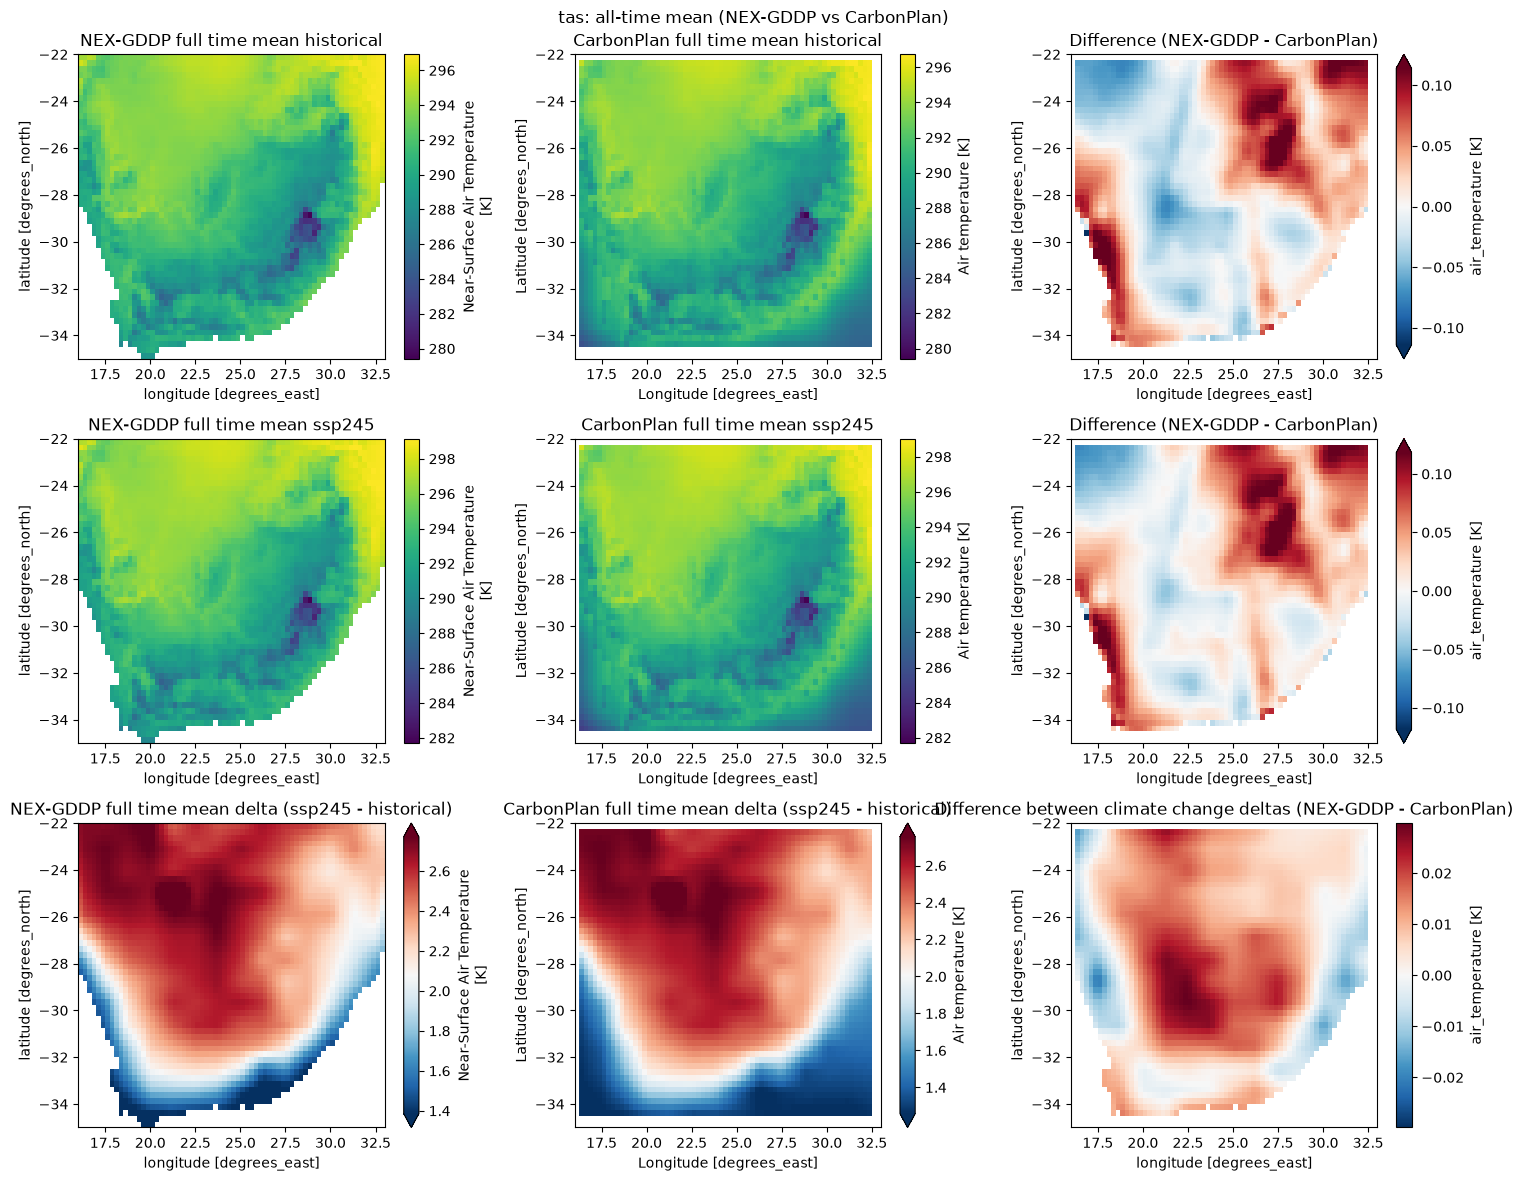

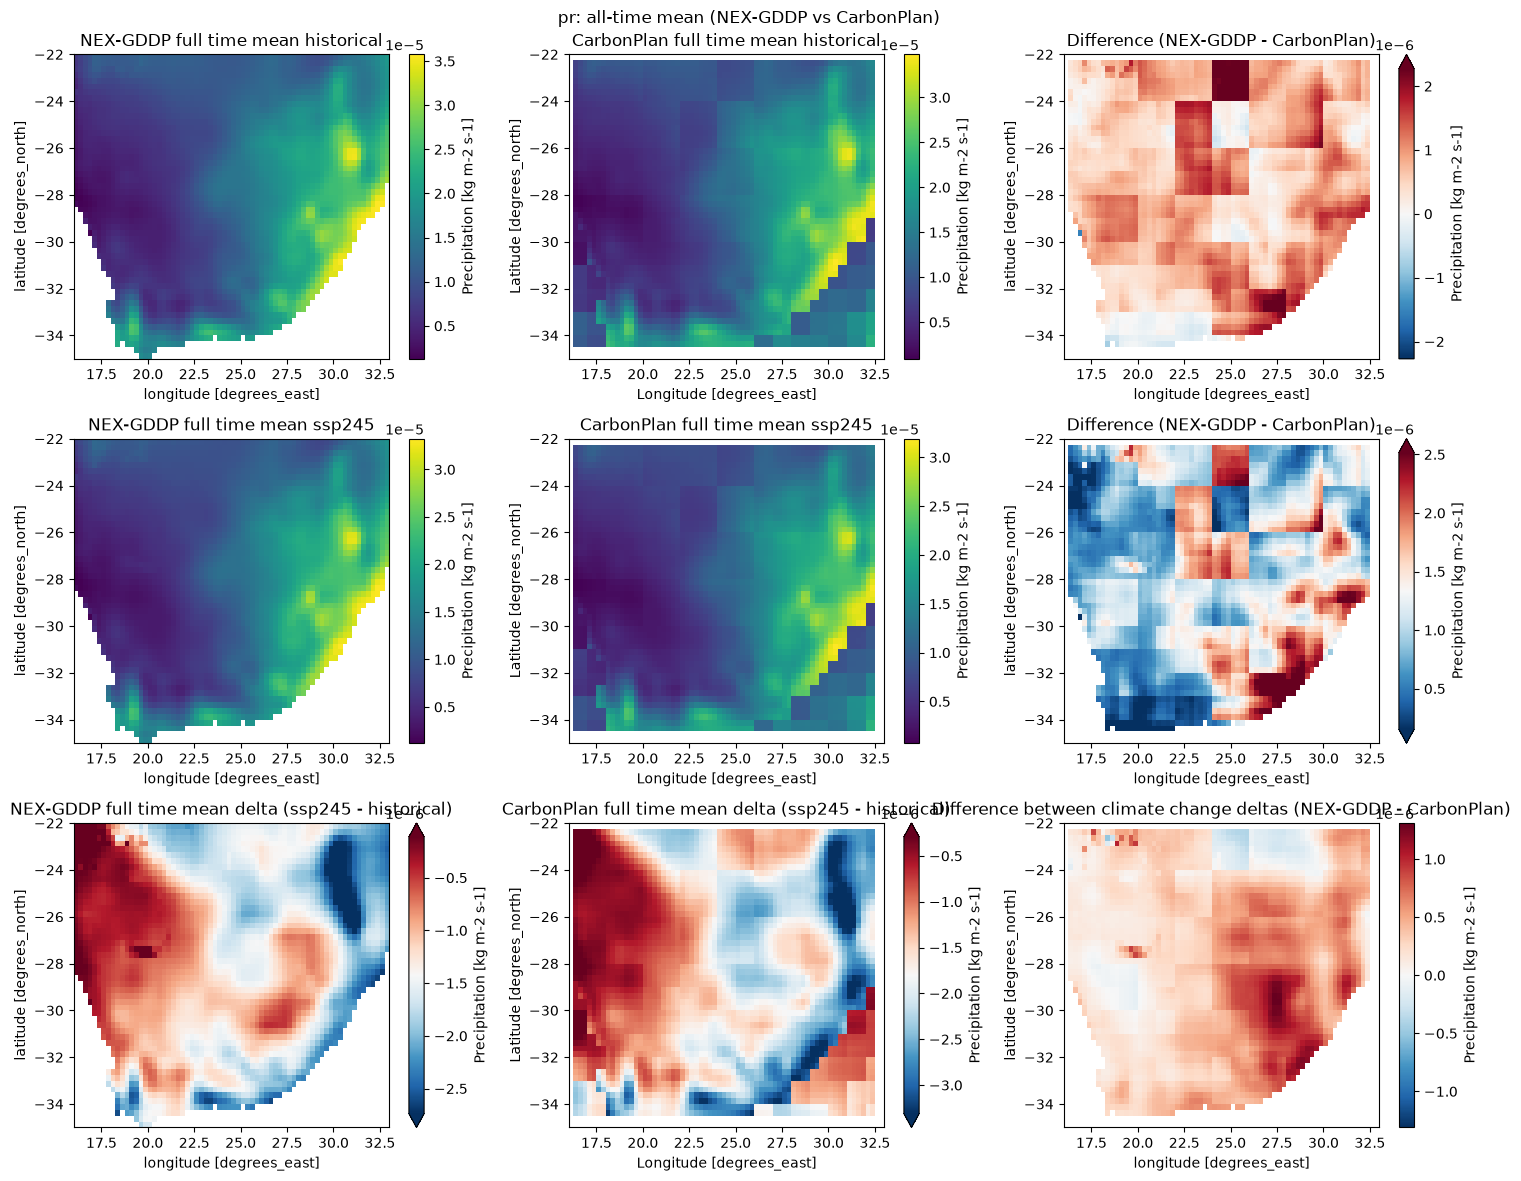

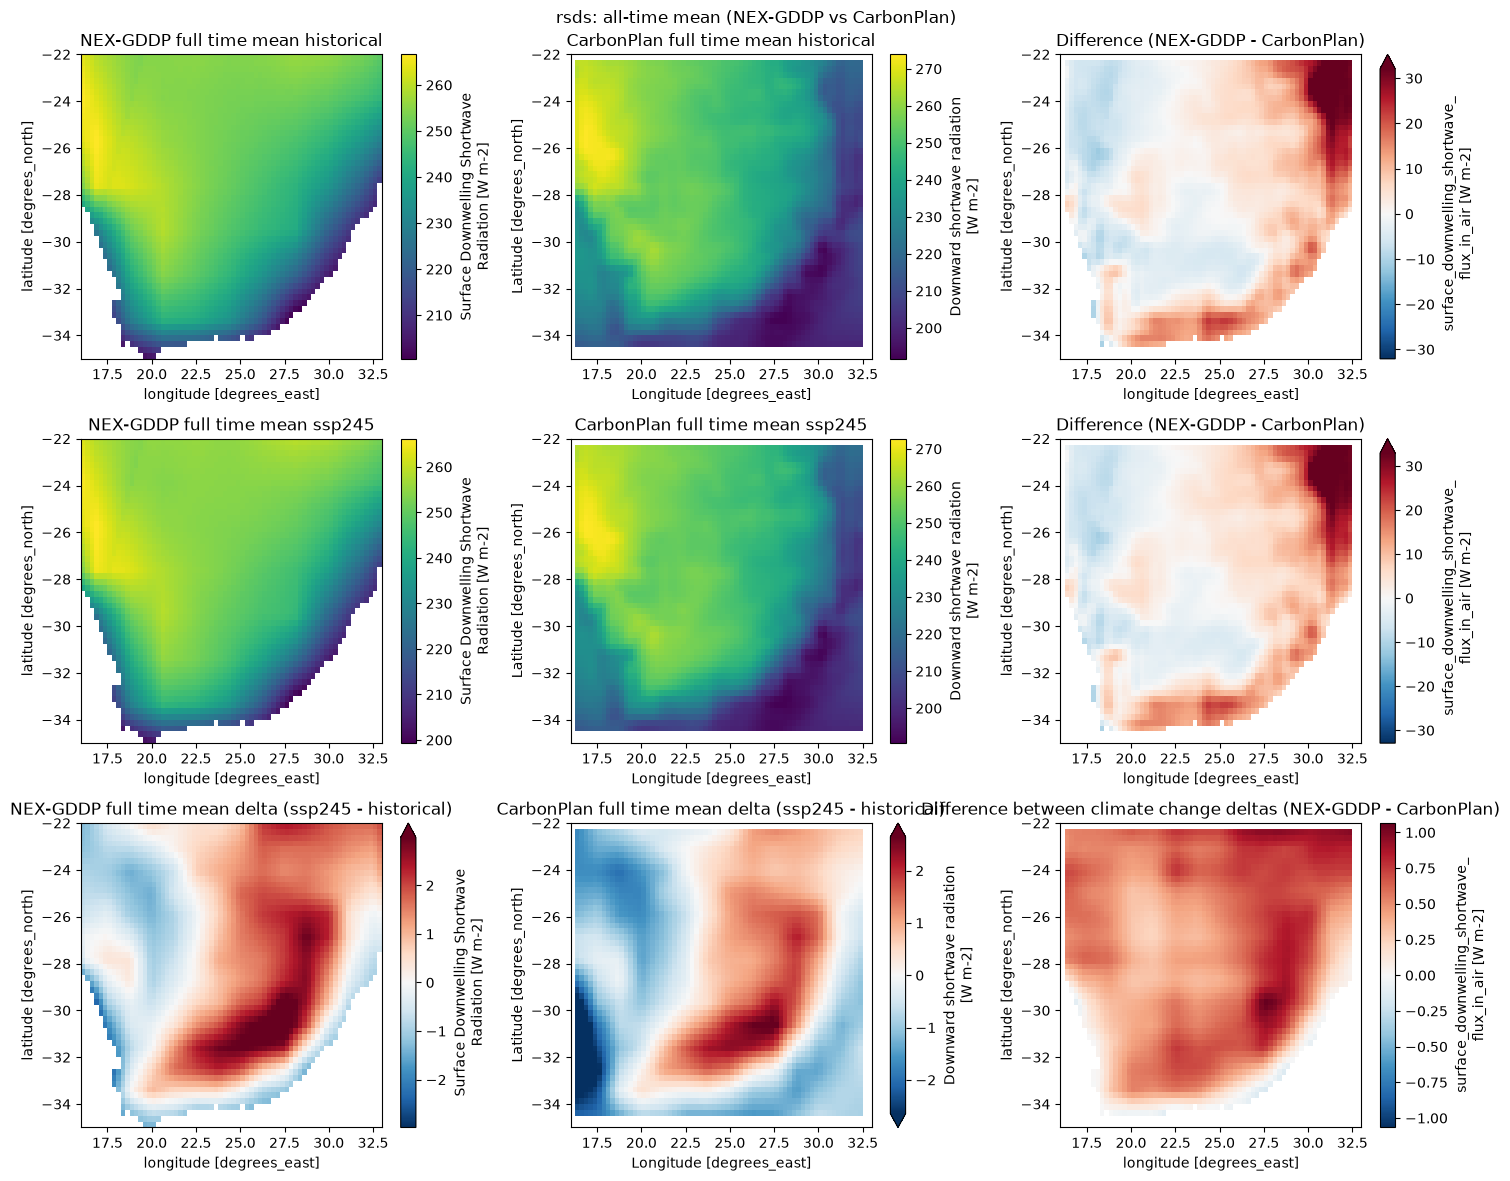

In [105]:
for variable in ["tas", "pr", "rsds"]:
    plot_nine_panel(stats_dict, stat="mean", stat_label="all-time mean")

## 99th percentile

historical
tas
p99
ssp245
tas
p99
historical
pr
p99
ssp245
pr
p99
historical
rsds
p99
ssp245
rsds
p99


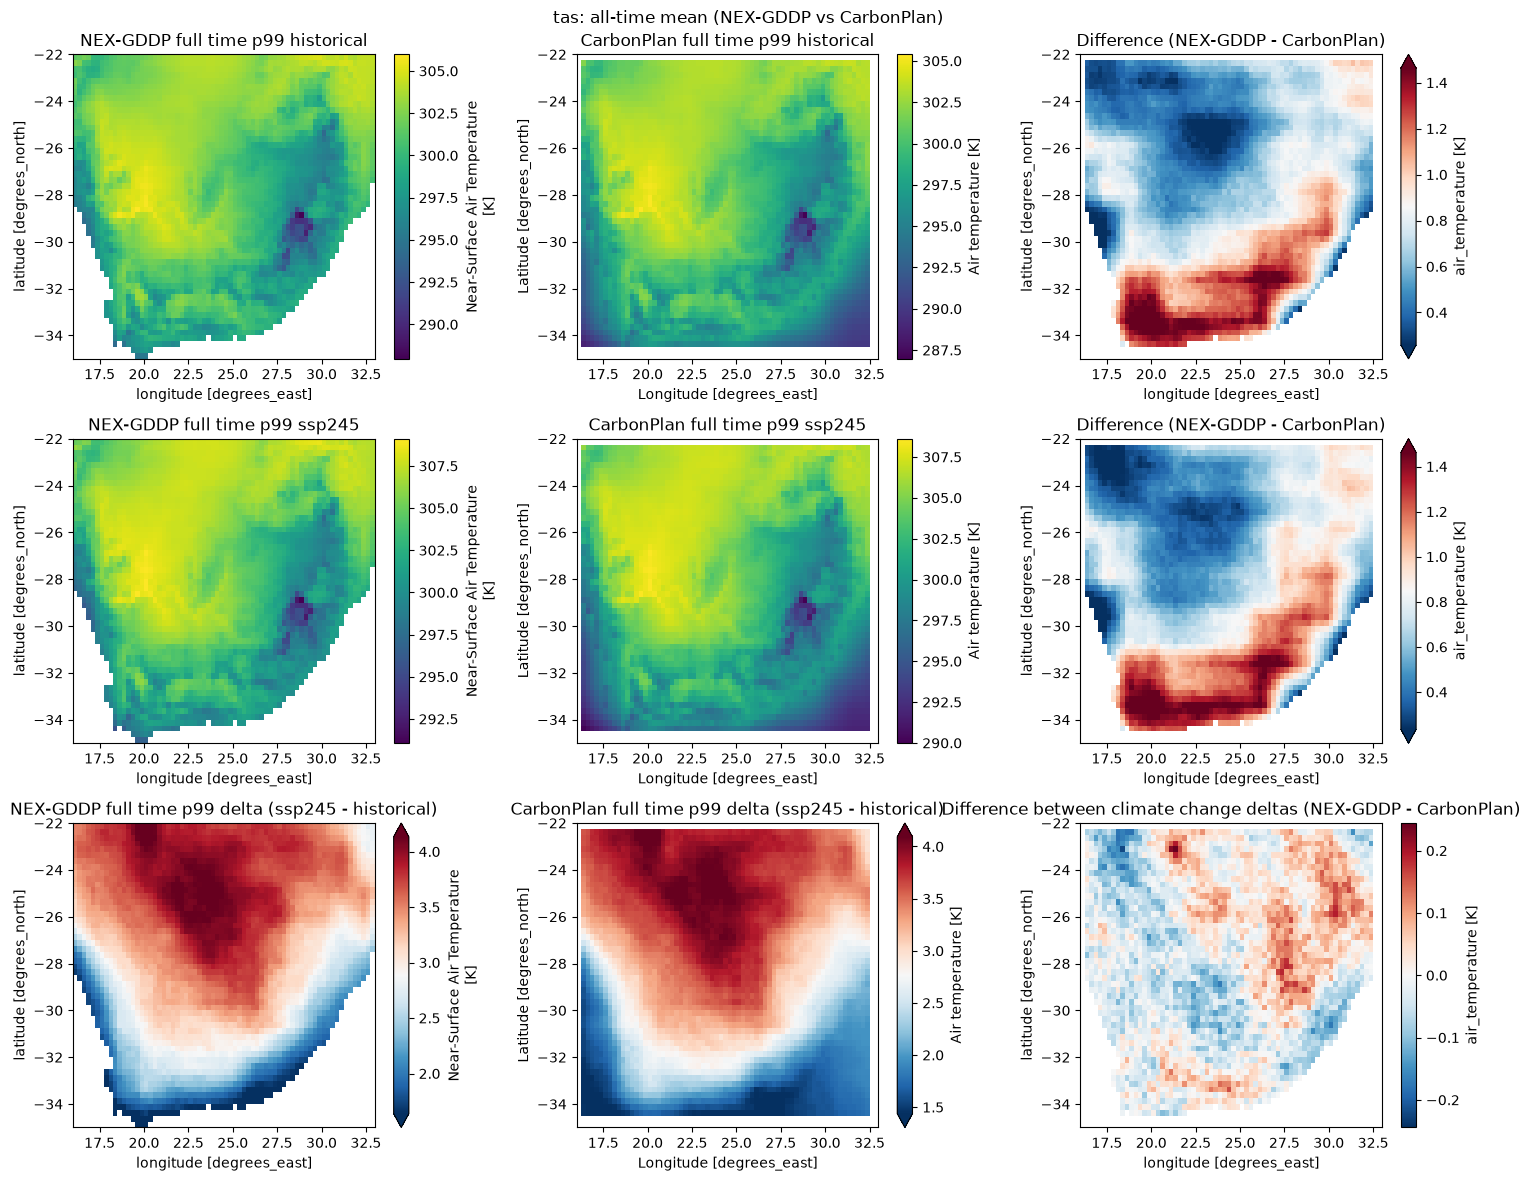

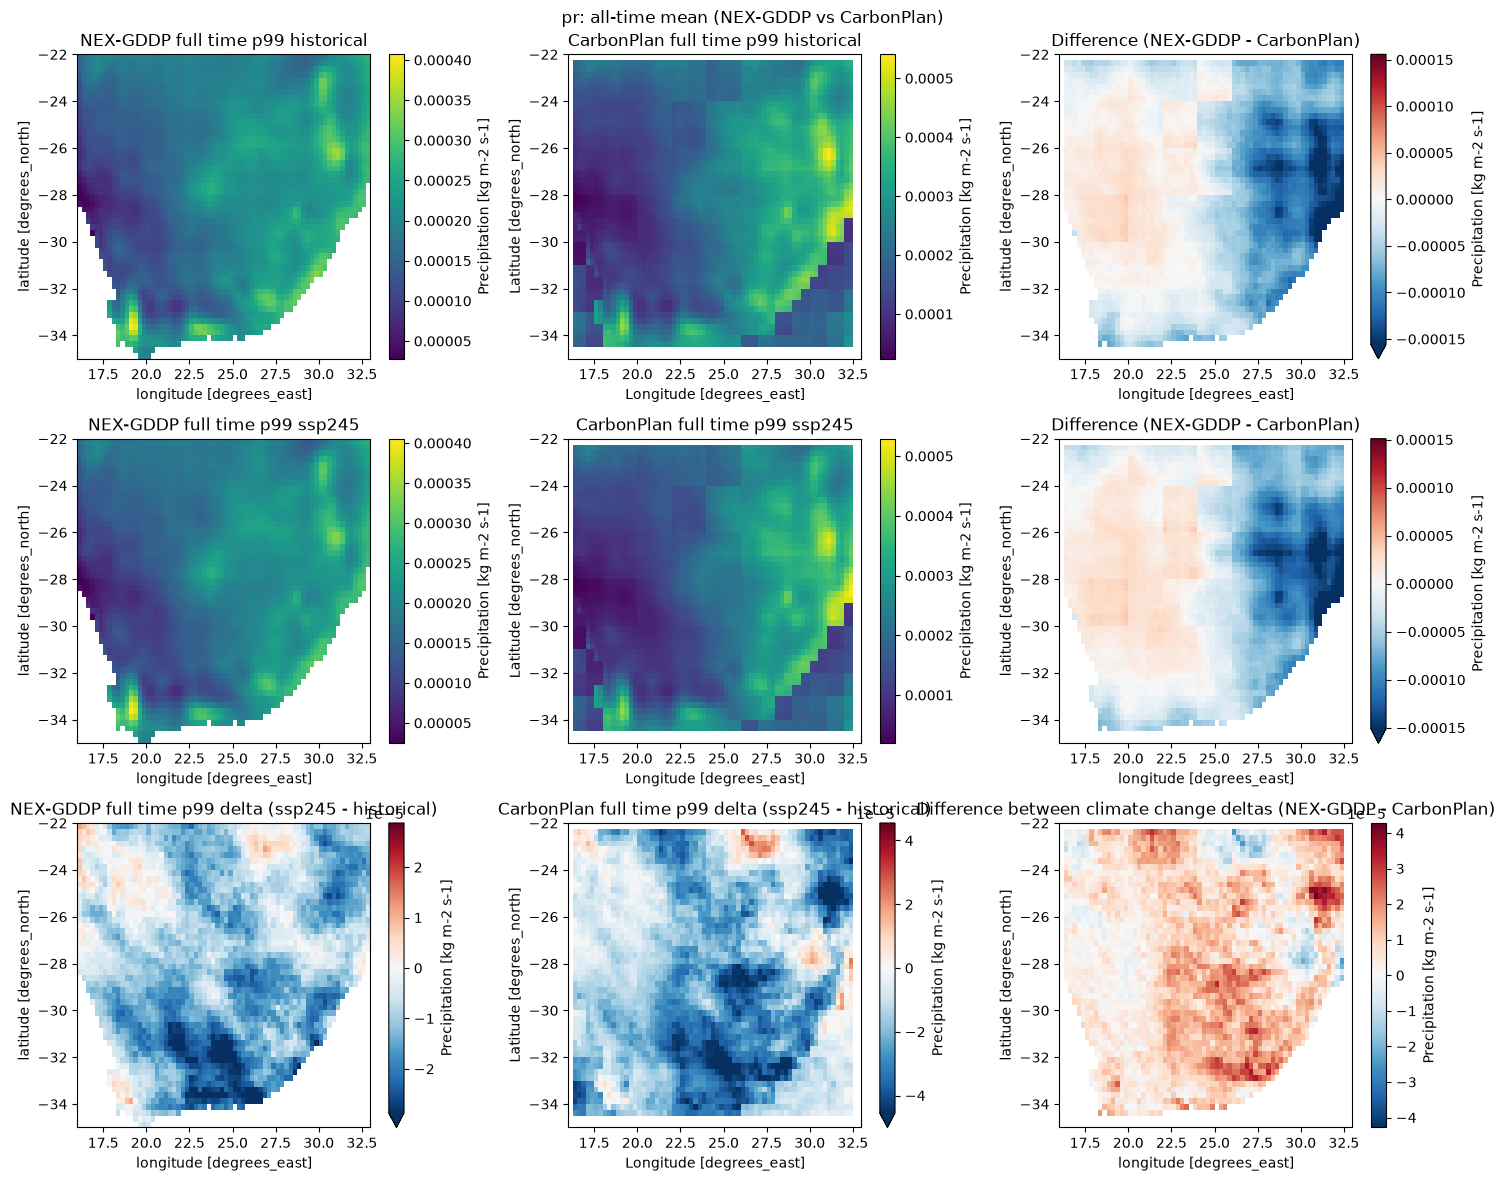

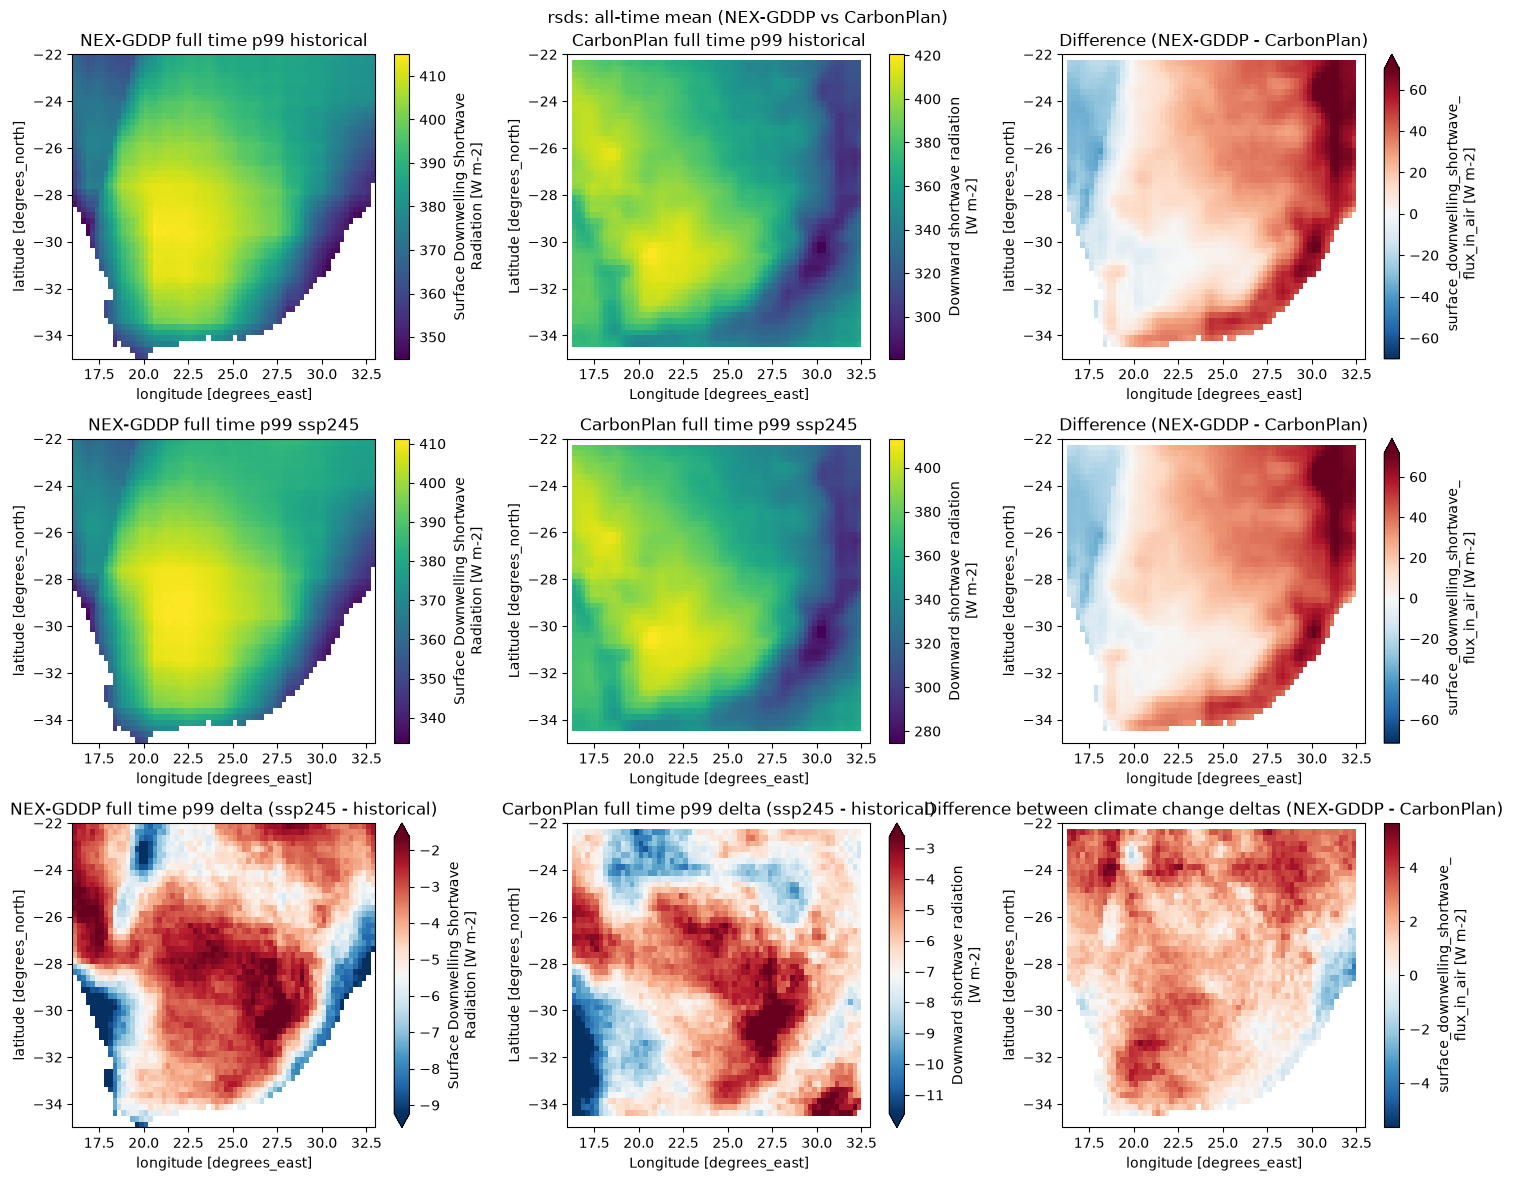

In [106]:
for variable in ["tas", "pr", "rsds"]:
    plot_nine_panel(stats_dict, stat="p99", stat_label="all-time mean")